Dataset:
    Age  Income Buy_House
0    22   25000        No
1    25   30000        No
2    27   35000        No
3    29   40000        No
4    31   28000       Yes
5    32   32000        No
6    34   45000       Yes
7    35   50000       Yes
8    36   35000        No
9    38   55000       Yes
10   40   40000        No
11   42   60000       Yes
12   45   45000       Yes
13   47   70000       Yes
14   50   50000       Yes
15   52   80000       Yes
16   55   60000       Yes
17   58   90000       Yes
18   60   75000       Yes
19   62  100000       Yes

Dataset Shape: (20, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Age        20 non-null     int64 
 1   Income     20 non-null     int64 
 2   Buy_House  20 non-null     object
dtypes: int64(2), object(1)
memory usage: 612.0+ bytes

Missing Values:
Age          0
Income       0
Buy_House    0
dtype: 

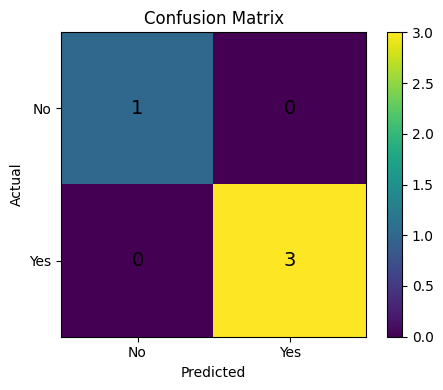


Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



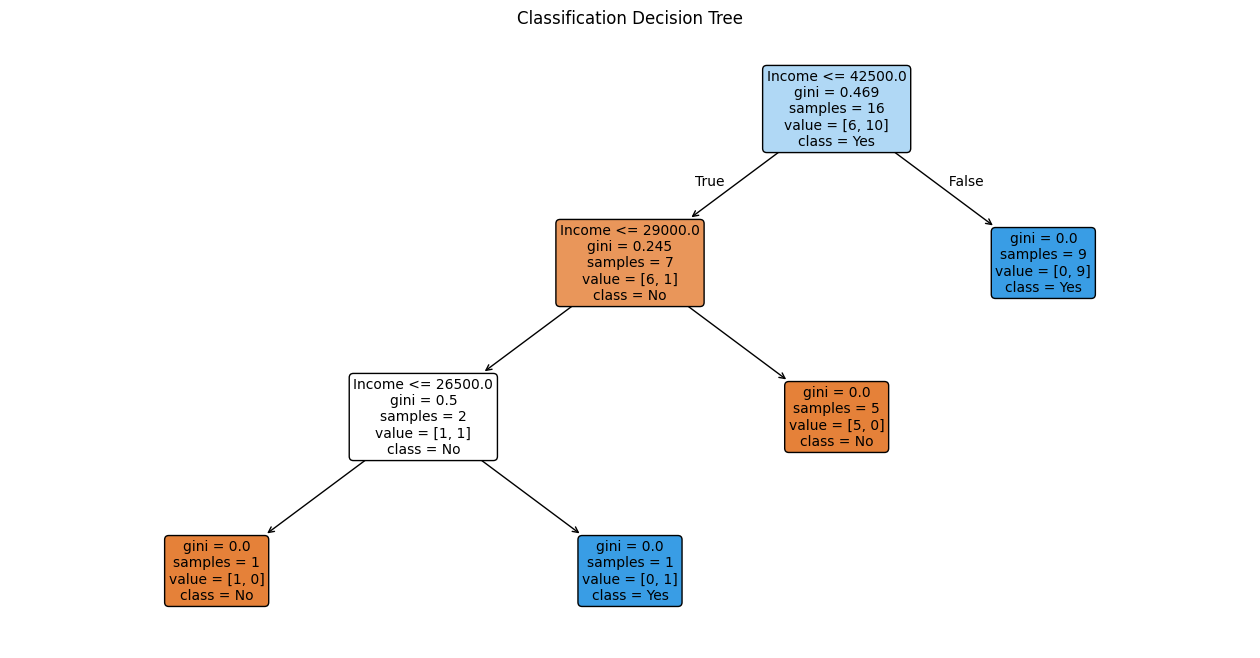

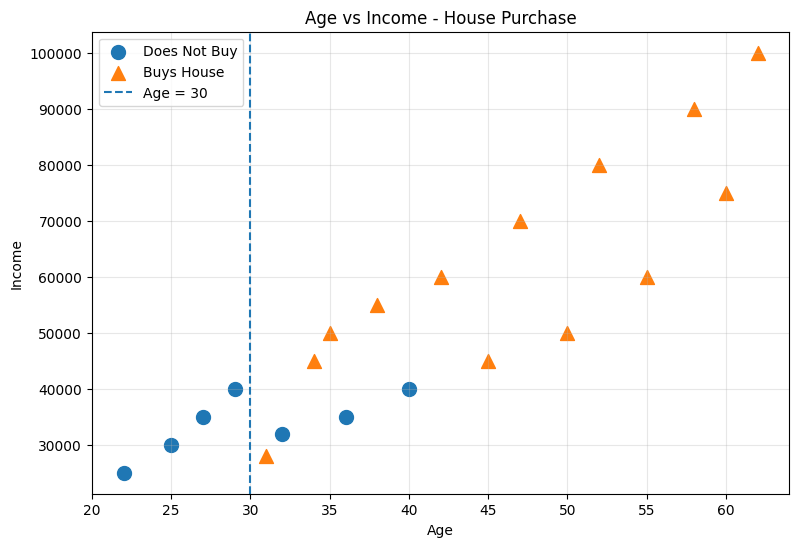


Predictions for New People:
 Age  Income Predicted_Buy_House  Probability_of_Buying
  25   30000                  No                    0.0
  35   50000                 Yes                    1.0
  45   60000                 Yes                    1.0
  55   90000                 Yes                    1.0

Decision Tree classification was successfully implemented.
The model predicts whether a person buys a house using Age and Income.
The model was evaluated using accuracy, confusion matrix, and classification report.
The decision tree was also visualized to understand the splitting process.


In [1]:
# 1. Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Create sample dataset

data = {
    'Age': [
        22, 25, 27, 29, 31, 32, 34, 35, 36, 38,
        40, 42, 45, 47, 50, 52, 55, 58, 60, 62
    ],
    'Income': [
        25000, 30000, 35000, 40000, 28000, 32000, 45000, 50000,
        35000, 55000, 40000, 60000, 45000, 70000, 50000, 80000,
        60000, 90000, 75000, 100000
    ],
    'Buy_House': [
        'No', 'No', 'No', 'No',
        'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes',
        'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes'
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)


# 3. Display dataset information

print("\nDataset Shape:", df.shape)
df.info()


# 4. Check for missing values

print("\nMissing Values:")
print(df.isnull().sum())


# 5. Display descriptive statistics

print("\nDescriptive Statistics:")
print(df.describe())


# 6. Display target variable distribution

print("\nHouse Purchase Distribution:")
print(df['Buy_House'].value_counts())


# 7. Convert target variable into numerical values

df['Buy_House_Code'] = df['Buy_House'].map({
    'No': 0,
    'Yes': 1
})


# 8. Define input and target variables

X = df[['Age', 'Income']]
y = df['Buy_House_Code']

print("\nInput Variables:")
print(X.head())

print("\nTarget Variable:")
print(y.head())


# 9. Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# 10. Create and train the Decision Tree model

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("\nDecision Tree Model trained successfully.")


# 11. Display tree information

print("\nTree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

print("\nFeature Importance:")

for feature, importance in zip(X.columns, model.feature_importances_):
    print(f"{feature}: {importance:.4f}")


# 12. Make predictions

y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Age': X_test['Age'].values,
    'Income': X_test['Income'].values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

results['Actual'] = results['Actual'].map({
    0: 'No',
    1: 'Yes'
})

results['Predicted'] = results['Predicted'].map({
    0: 'No',
    1: 'Yes'
})

print("\nPredictions:")
print(results.to_string(index=False))


# 13. Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# 14. Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

plt.colorbar()
plt.tight_layout()
plt.show()


# 15. Display classification report

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=['No', 'Yes'],
    zero_division=0
))


# 16. Visualize the Decision Tree

plt.figure(figsize=(16, 8))

plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Classification Decision Tree")
plt.show()


# 17. Visualize Age and Income distribution

plt.figure(figsize=(9, 6))

for label, marker in [(0, 'o'), (1, '^')]:
    subset = df[df['Buy_House_Code'] == label]

    plt.scatter(
        subset['Age'],
        subset['Income'],
        label='Does Not Buy' if label == 0 else 'Buys House',
        marker=marker,
        s=100
    )

plt.axvline(
    x=30,
    linestyle='--',
    label='Age = 30'
)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age vs Income - House Purchase")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 18. Predict house purchase for new people

new_people = pd.DataFrame({
    'Age': [25, 35, 45, 55],
    'Income': [30000, 50000, 60000, 90000]
})

predictions = model.predict(new_people)
probabilities = model.predict_proba(new_people)[:, 1]

new_people['Predicted_Buy_House'] = np.where(
    predictions == 1,
    'Yes',
    'No'
)

new_people['Probability_of_Buying'] = probabilities

print("\nPredictions for New People:")
print(new_people.to_string(index=False))


# 19. Conclusion

print("\nDecision Tree classification was successfully implemented.")
print("The model predicts whether a person buys a house using Age and Income.")
print("The model was evaluated using accuracy, confusion matrix, and classification report.")
print("The decision tree was also visualized to understand the splitting process.")